# Camera alignment for new (inpainted) cameras — diagnostic notebook

**Problem.** In the demo we create a *new* camera, generate a frame for it (the
inpainting model is our frame generator), then hand it to Lyra to reconstruct —
and the new geometry lands *somewhere else*.

**This notebook** reproduces and bisects that, in a minimal setup, **before**
touching the live demo. It:

1. Builds a **base scene** by running **fresh DA3** on a short clip (the
   ground-truth world frame W, in DA3-native scale).
2. Creates a **known new camera B** in W.
3. **Proves the OpenCV-w2c convention** with a no-model round-trip (Section 3).
4. Builds + compares **both depth paths** for adding B back:
   - **Path A** — splat-rendered depth (today's inpaint-tab path). Disoccluded
     pixels have α=0 ⇒ depth=0 ⇒ they collapse to the camera origin.
   - **Path B** — re-estimate depth with **DA3** and **scale-align** to the
     scene (point-A similarity + Umeyama Sim3 + overlap fit + MoGe).
5. Overlays everything and prints the same metrics the live diagnostic uses
   (position / angular error, depth-scale ratio).

> Run with the **`lyra2`** conda env (kernel or `conda run -n lyra2`) — DA3 needs
> the libcudart shim. Reuses helpers from `splat_trainer`, `depth_utils`,
> `lyra2_zoomgs_inference`, `vipe_da3_gs_recon`, `depth_anything_3.utils.pose_align`.

In [1]:
import os, sys, math, tempfile
from types import SimpleNamespace
from pathlib import Path
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)

ROOT    = "/home/kristofe/Documents/Projects/lyra/Lyra-2"
DA3_SRC = os.path.join(ROOT, "lyra_2/_src/inference/depth_anything_3/src")
for p in (DA3_SRC, os.path.join(ROOT, "visergui"), ROOT):
    if p not in sys.path:
        sys.path.insert(0, p)
# keep any stray .ply writes from reused helpers inside the notebook dir
os.makedirs(os.path.join(ROOT, "visergui", "notebooks", "_scratch"), exist_ok=True)
os.chdir(os.path.join(ROOT, "visergui", "notebooks", "_scratch"))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)
np.random.seed(0); torch.manual_seed(0)

# gsplat JIT-rebuilds on a cold/stale extension cache; the host compile of ext.cpp
# needs cuda_runtime_api.h, which lives under $PREFIX/targets/.../include (not include/).
# Prepend it to CPATH BEFORE importing gsplat so a rebuild can find the CUDA headers.
_cuda_inc = os.path.join(sys.prefix, "targets", "x86_64-linux", "include")
if os.path.isdir(_cuda_inc):
    os.environ["CPATH"] = _cuda_inc + os.pathsep + os.environ.get("CPATH", "")

import gsplat
from depth_anything_3.utils.pose_align import align_poses_umeyama
import splat_trainer as st                      # _extract_frames, _estimate_depth_scale, _da3_inference_on_paths
from lyra_2._src.inference.depth_utils import (
    load_da3_model, load_moge_model, moge_infer_depth_intrinsics)
from lyra_2._src.inference.lyra2_zoomgs_inference import _da3_infer_depth_intrinsics_single
print("device:", device, "| torch:", torch.__version__)

C0 = 0.28209479177387814  # SH DC constant (matches splat_trainer._build_initial_gaussians)

[06-22 12:34:34|INFO|../../../lyra_2/_ext/imaginaire/checkpointer/dcp.py:195:<module>] for the back comptiable pytorch! New DefaultLoadPlanner class is created.
device: cuda | torch: 2.7.1+cu128


In [2]:
# ----------------------------- reusable helpers (thin wrappers over repo code) --
def pix_grid(H, W):
    ii, jj = torch.meshgrid(torch.arange(H, device=device),
                            torch.arange(W, device=device), indexing="ij")
    return torch.stack([jj, ii, torch.ones_like(ii)], -1).float()   # (H,W,3) [u,v,1]

def render_scene(scene, w2c, K, H, W):
    # gsplat RGB+ED, returns rgb_uint8(H,W,3), depth(H,W), alpha(H,W) numpy.
    # Mirrors inpainter._render_splats / nbv_trajectory._render_rgbd.
    w2c = torch.as_tensor(w2c, dtype=torch.float32, device=device).reshape(1, 4, 4)
    K   = torch.as_tensor(K,   dtype=torch.float32, device=device).reshape(1, 3, 3)
    sh = scene.sh
    sh_deg = int(round(sh.shape[1] ** 0.5)) - 1
    out, alpha, _ = gsplat.rasterization(
        means=scene.means, quats=torch.nn.functional.normalize(scene.quats, dim=-1),
        scales=scene.scales, opacities=scene.opacities, colors=sh,
        viewmats=w2c, Ks=K, width=int(W), height=int(H),
        sh_degree=sh_deg, packed=False, render_mode="RGB+ED")
    a = alpha[0, :, :, 0].clamp(0, 1)
    rgb = (out[0, :, :, :3].clamp(0, 1).cpu().numpy() * 255).astype(np.uint8)
    depth = (out[0, :, :, 3] / a.clamp_min(1e-6)).cpu().numpy()
    return rgb, depth, a.cpu().numpy()

def unproject(depth_hw, K_33, c2w_44):
    # Backproject a depth map -> world points (H,W,3). Mirrors _build_initial_gaussians 462-470.
    depth_hw = torch.as_tensor(depth_hw, dtype=torch.float32, device=device)
    K   = torch.as_tensor(K_33,  dtype=torch.float32, device=device)
    c2w = torch.as_tensor(c2w_44, dtype=torch.float32, device=device)
    H, W = depth_hw.shape
    cam = torch.einsum("ij,hwj->hwi", torch.linalg.inv(K), pix_grid(H, W)) * depth_hw[..., None]
    return torch.einsum("ij,hwj->hwi", c2w[:3, :3], cam) + c2w[:3, 3]

def pose_errors(c2w_rec, c2w_true):
    a = np.asarray(c2w_rec, np.float64); b = np.asarray(c2w_true, np.float64)
    pos = float(np.linalg.norm(a[:3, 3] - b[:3, 3]))
    Rrel = a[:3, :3] @ b[:3, :3].T
    ang = math.degrees(math.acos(max(-1.0, min(1.0, (np.trace(Rrel) - 1.0) / 2.0))))
    return pos, ang

def apply_sim3_to_c2w(c2w, r, t, s):
    # est->ref similarity, exactly as vipe_da3_gs_recon._compute_aligned_pred_w2c (347-351).
    c2w = np.asarray(c2w, np.float64).reshape(-1, 4, 4)
    r = np.asarray(r, np.float64); t = np.asarray(t, np.float64).reshape(3); s = float(s)
    r_inv = r.T
    out = np.zeros_like(c2w)
    out[:, :3, :3] = np.einsum("ij,njk->nik", r_inv, c2w[:, :3, :3])
    out[:, :3, 3]  = np.einsum("ij,nj->ni", r_inv, c2w[:, :3, 3] - t[None, :]) / s
    out[:, 3, 3] = 1.0
    return out

def show_overlay(groups, title, cams=None, n=4000, elev=18, azim=-72):
    fig = plt.figure(figsize=(7.5, 6.2)); ax = fig.add_subplot(111, projection="3d")
    for pts, color, label in groups:
        p = np.asarray(pts).reshape(-1, 3)
        p = p[np.isfinite(p).all(1)]
        if p.shape[0] > n:
            p = p[np.random.choice(p.shape[0], n, replace=False)]
        ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=1.0, c=color, label=label, alpha=0.5)
    for c2w, col, lab in (cams or []):
        cc = np.asarray(c2w)[:3, 3]
        ax.scatter([cc[0]], [cc[1]], [cc[2]], s=70, marker="^", c=col, label=lab, edgecolors="k")
    ax.set_title(title); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.legend(loc="upper right", fontsize=7); ax.view_init(elev=elev, azim=azim)
    try: ax.set_box_aspect((1, 1, 1))
    except Exception: pass
    plt.tight_layout(); plt.show()
print("helpers ready")

helpers ready


In [3]:
# ------------------------- side-effect-free base-scene builder + DA3 packers ----
def make_scene(data, max_points=500_000, conf_q=0.5, remove_sky=True):
    # Unproject base RGBD into a renderable gsplat scene (no .ply writes, unlike
    # splat_trainer._build_initial_gaussians). scales/opacities are ALREADY activated.
    H, W = int(data.H), int(data.W)
    Kinv = torch.linalg.inv(data.K)                                  # (N,3,3)
    cam  = torch.einsum("nij,hwj->nhwi", Kinv, pix_grid(H, W)) * data.depth[..., None]
    world = torch.einsum("nij,nhwj->nhwi", data.c2w[:, :3, :3], cam) + data.c2w[:, :3, 3][:, None, None, :]
    valid = data.depth > 0
    if getattr(data, "sky", None) is not None and remove_sky:
        valid &= ~data.sky.bool()
    if getattr(data, "conf", None) is not None:
        cf = data.conf.flatten().float()
        step = max(1, cf.numel() // 2_000_000)
        thr = torch.quantile(cf[::step], conf_q)
        valid &= data.conf > thr
    pts  = world[valid]; cols = data.rgb[valid]; z = data.depth[valid]
    fx   = data.K[:, 0, 0][:, None, None].expand(data.N, H, W)[valid]
    n_valid = int(pts.shape[0])
    if n_valid > max_points:
        sel = torch.randperm(n_valid, device=device)[:max_points]
        pts, cols, z, fx = pts[sel], cols[sel], z[sel], fx[sel]
    ratio = max(1.0, n_valid / max(1, pts.shape[0]))
    tex = (z / fx * (ratio ** 0.5)).clamp_min(1e-4)
    M = int(pts.shape[0])
    scene = SimpleNamespace(
        means=pts.contiguous().float(),
        quats=torch.tensor([1., 0, 0, 0], device=device).expand(M, 4).contiguous(),
        scales=tex[:, None].expand(M, 3).contiguous().float(),
        opacities=torch.full((M,), 0.9, device=device),
        sh=((cols - 0.5) / C0)[:, None, :].contiguous().float())
    scene_scale = float(pts.std(dim=0).mean().item())
    return scene, scene_scale

def da3_pack(model, paths):
    # Same packing as splat_trainer._da3_inference_on_paths, but reuses a preloaded model.
    pred = model.inference(image=list(paths), process_res=504,
                           process_res_method="upper_bound_resize")
    imgs  = torch.from_numpy(pred.processed_images).to(device)        # (N,H,W,3) uint8
    depth = torch.from_numpy(pred.depth).to(device)                   # (N,H,W)
    K     = torch.from_numpy(pred.intrinsics).to(device)              # (N,3,3)
    w2c34 = torch.from_numpy(pred.extrinsics).to(device)              # (N,3,4) OpenCV w2c
    N, H, W, _ = imgs.shape
    w2c = torch.eye(4, device=device).expand(N, 4, 4).clone(); w2c[:, :3, :4] = w2c34
    conf = getattr(pred, "conf", None); conf = getattr(pred, "confidence", None) if conf is None else conf
    sky  = getattr(pred, "sky", None)
    return SimpleNamespace(
        rgb=imgs.float() / 255.0, depth=depth, K=K, w2c=w2c, c2w=torch.linalg.inv(w2c),
        conf=(torch.from_numpy(conf).to(device) if conf is not None else None),
        sky=(torch.from_numpy(sky).to(device).bool() if sky is not None else None),
        N=N, H=H, W=W)
print("scene + DA3 packers ready")

scene + DA3 packers ready


## Section 2 — Base scene (fresh DA3 on a clip)

Extract a handful of frames from `assets/ours/museum_fwd.mp4`, run DA3 over them
(this is exactly what `splat_trainer._da3_inference_on_paths` does for the live
viewer), and unproject into a renderable scene. This DA3-native frame **W** is our
ground truth: all later cameras/points are judged against it.

In [4]:
VIDEO      = os.path.join(ROOT, "assets/ours/museum_fwd.mp4")
N_FRAMES   = 10
DA3_NAME   = "depth-anything/DA3NESTED-GIANT-LARGE-1.1"
USE_CUSTOM_RECON = False   # True -> checkpoints/recon/model.pt (the demo_server DA3)

frames_dir = os.path.join(os.getcwd(), "frames_base")
base_paths = st._extract_frames(Path(VIDEO), Path(frames_dir), N_FRAMES)
print(f"extracted {len(base_paths)} frames")

da3_model = load_da3_model(
    da3_model_name=DA3_NAME,
    da3_model_path_custom=(os.path.join(ROOT, "checkpoints/recon/model.pt") if USE_CUSTOM_RECON else None),
    device=str(device))

base_data = da3_pack(da3_model, base_paths)
base_scene, scene_scale = make_scene(base_data)
print(f"base: N={base_data.N}  HxW={base_data.H}x{base_data.W}  "
      f"gaussians={base_scene.means.shape[0]}  scene_scale={scene_scale:.3f}")
print("base camera centers:\n", base_data.c2w[:, :3, 3].cpu().numpy().round(3))

10 frames @ stride 8 from 81 total
extracted 10 frames
Error registering eval resolver: resolver 'eval' is already registered
[INFO ] using SwiGLU layer as FFN
[INFO ] using MLP layer as FFN
[INFO ] Processed Images Done taking 0.03374671936035156 seconds. Shape:  torch.Size([10, 3, 294, 504])
[INFO ] Selecting reference view using strategy: saddle_balanced
b_idx: tensor([8], device='cuda:0')
[INFO ] Model Forward Pass Done. Time: 0.7889909744262695 seconds
[INFO ] Conversion to Prediction Done. Time: 0.005799055099487305 seconds
base: N=10  HxW=294x504  gaussians=500000  scene_scale=2.192
base camera centers:
 [[ 3.000e-03 -0.000e+00 -2.224e+00]
 [ 1.000e-03  4.000e-03 -1.929e+00]
 [-0.000e+00  5.000e-03 -1.653e+00]
 [ 0.000e+00  9.000e-03 -1.369e+00]
 [-2.000e-03  8.000e-03 -1.091e+00]
 [ 6.000e-03  1.000e-02 -8.190e-01]
 [ 3.000e-03  8.000e-03 -5.540e-01]
 [-1.000e-03  6.000e-03 -2.720e-01]
 [-2.000e-03  0.000e+00 -1.000e-03]
 [ 3.000e-03  6.000e-03  2.690e-01]]


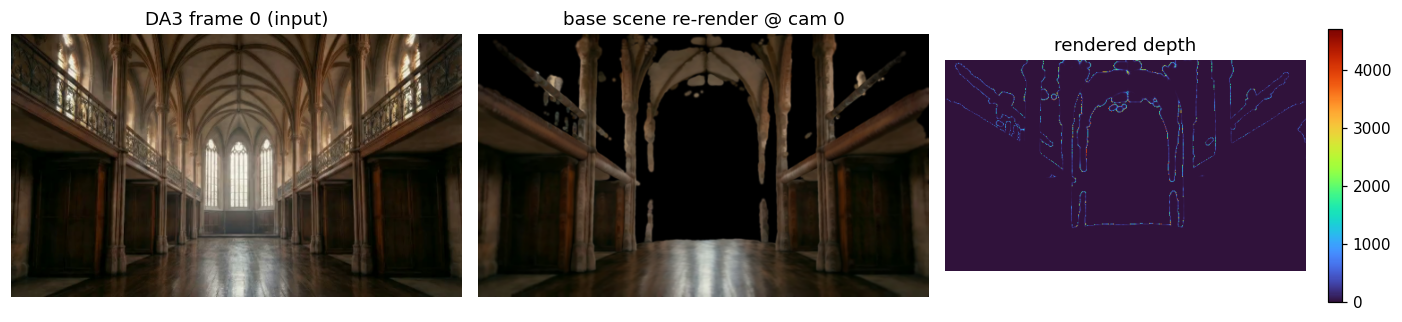

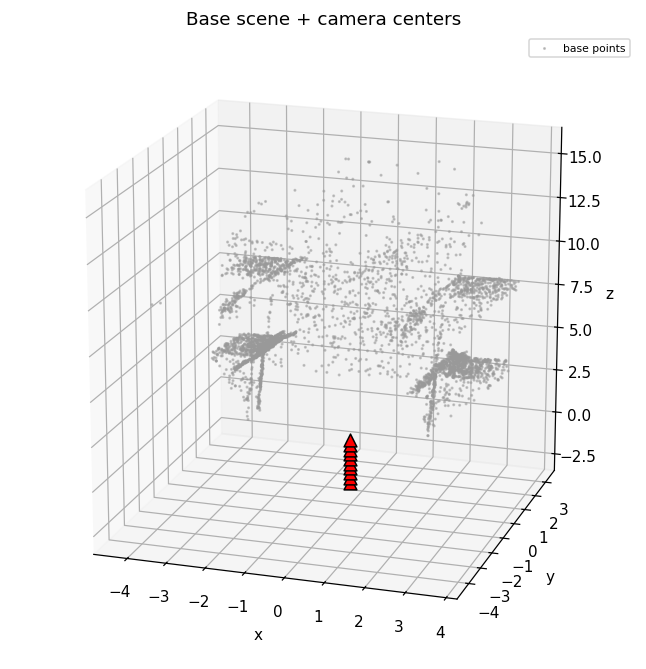

In [5]:
# Sanity: show frame 0 + a re-render of the base scene from base camera 0.
i0 = 0
rgb0 = (base_data.rgb[i0].cpu().numpy() * 255).astype(np.uint8)
rr, rd, ra = render_scene(base_scene, base_data.w2c[i0], base_data.K[i0], base_data.H, base_data.W)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].imshow(rgb0);           ax[0].set_title("DA3 frame 0 (input)")
ax[1].imshow(rr);             ax[1].set_title("base scene re-render @ cam 0")
im = ax[2].imshow(rd, cmap="turbo"); ax[2].set_title("rendered depth"); fig.colorbar(im, ax=ax[2], shrink=0.8)
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
show_overlay([(base_scene.means.cpu().numpy(), "0.6", "base points")],
             "Base scene + camera centers",
             cams=[(base_data.c2w[i].cpu().numpy(), "red", None) for i in range(base_data.N)])

## Section 3 — Convention round-trip (NO models)

Pick base camera **A**, build a **known new camera B** as a pure-translation offset
of A (so B sees mostly the same geometry). Render the base scene from B, then
backproject B's rendered depth with B's `c2w` and check the points land back on the
base gaussians.

✅ If they overlap, the OpenCV `w2c`/`c2w` + intrinsics handling is correct and the
demo's misalignment is **not** a convention bug — it's depth/scale grounding.
We also round-trip B through `viewer.viser_camera_to_opencv_viewmat` to confirm the
viser↔OpenCV path the demo uses introduces no basis flip.

B baseline = 0.548 (25% of scene_scale)
seen pixels: 63.3%
backprojected-B -> nearest base point: median=0.0340  mean=0.1375  (scene_scale=2.192)


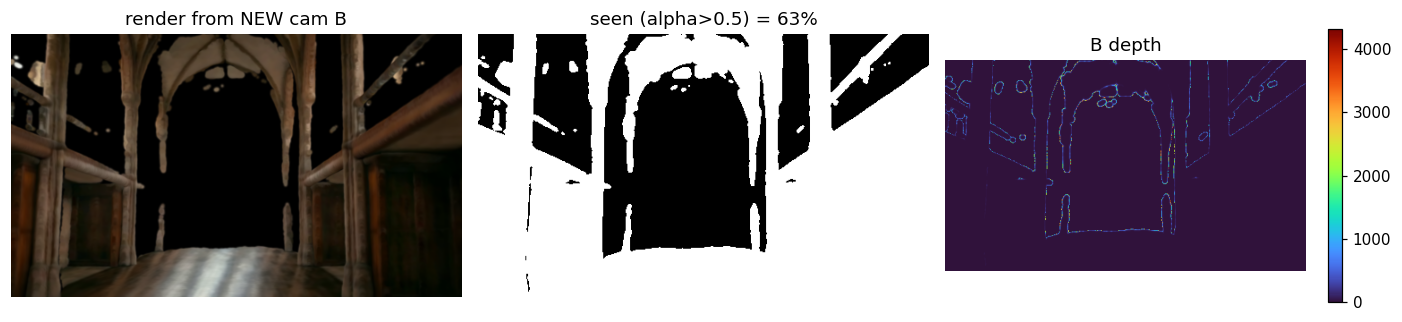

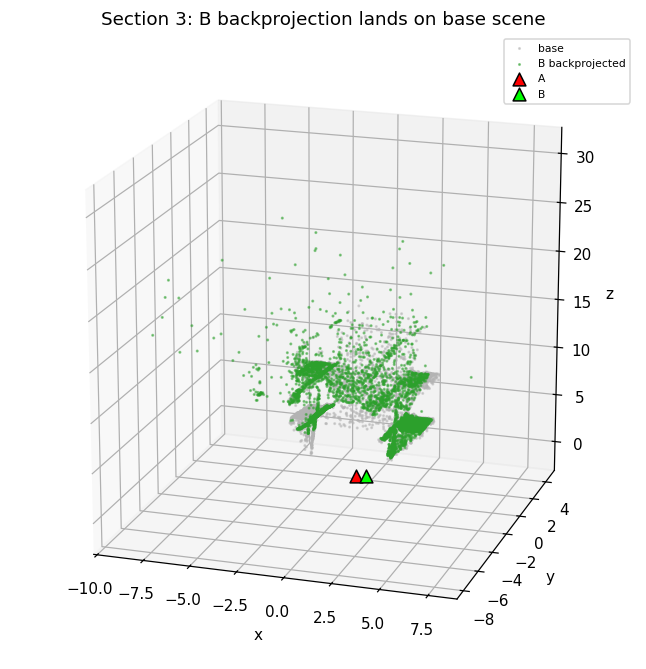

In [6]:
A_IDX        = base_data.N // 2
BASELINE_FRAC = 0.25                       # B offset as a fraction of scene_scale
c2w_A = base_data.c2w[A_IDX].clone()
K_B   = base_data.K[A_IDX].clone()
H_B, W_B = base_data.H, base_data.W

def make_B(c2w_A, baseline_frac, yaw_deg=0.0):
    # Pure translation along the camera's right (+x) & a touch of forward (+z),
    # plus optional yaw about the camera up (-y). All in OpenCV camera axes.
    c2w_B = c2w_A.clone()
    right, up, fwd = c2w_A[:3, 0], c2w_A[:3, 1], c2w_A[:3, 2]
    d = baseline_frac * scene_scale
    c2w_B[:3, 3] = c2w_A[:3, 3] + d * right + 0.2 * d * fwd
    if abs(yaw_deg) > 1e-6:
        th = math.radians(yaw_deg)
        axis = up / up.norm()
        K = torch.tensor([[0, -axis[2], axis[1]],
                          [axis[2], 0, -axis[0]],
                          [-axis[1], axis[0], 0]], device=device, dtype=torch.float32)
        Rdelta = torch.eye(3, device=device) + math.sin(th) * K + (1 - math.cos(th)) * (K @ K)
        c2w_B[:3, :3] = Rdelta @ c2w_A[:3, :3]
    return c2w_B

c2w_B = make_B(c2w_A, BASELINE_FRAC, yaw_deg=0.0)
w2c_B = torch.linalg.inv(c2w_B)

rgb_B, depth_B, alpha_B = render_scene(base_scene, w2c_B, K_B, H_B, W_B)
seen = alpha_B > 0.5
pts_B_world = unproject(depth_B, K_B, c2w_B)[torch.from_numpy(seen).to(device)].cpu().numpy()

# Nearest-base-point distance for the backprojected B points (should be ~0).
import scipy.spatial
base_np = base_scene.means.cpu().numpy()
tree = scipy.spatial.cKDTree(base_np[np.random.choice(base_np.shape[0], min(200000, base_np.shape[0]), replace=False)])
dist, _ = tree.query(pts_B_world[np.random.choice(pts_B_world.shape[0], min(20000, pts_B_world.shape[0]), replace=False)])
print(f"B baseline = {BASELINE_FRAC*scene_scale:.3f} ({BASELINE_FRAC:.0%} of scene_scale)")
print(f"seen pixels: {seen.mean():.1%}")
print(f"backprojected-B -> nearest base point: median={np.median(dist):.4f}  "
      f"mean={dist.mean():.4f}  (scene_scale={scene_scale:.3f})")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].imshow(rgb_B); ax[0].set_title("render from NEW cam B")
ax[1].imshow(seen, cmap="gray"); ax[1].set_title(f"seen (alpha>0.5) = {seen.mean():.0%}")
im = ax[2].imshow(depth_B, cmap="turbo"); ax[2].set_title("B depth"); fig.colorbar(im, ax=ax[2], shrink=0.8)
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
show_overlay([(base_np, "0.7", "base"), (pts_B_world, "tab:green", "B backprojected")],
             "Section 3: B backprojection lands on base scene",
             cams=[(c2w_A.cpu().numpy(), "red", "A"), (c2w_B.cpu().numpy(), "lime", "B")])

In [7]:
# viser <-> OpenCV round-trip: convert B's c2w to a viser (position, wxyz) and back
# through the exact helper the demo uses; recovered w2c must equal w2c_B.
try:
    from viewer import viser_camera_to_opencv_viewmat, _rotmat_to_wxyz
    pos = c2w_B[:3, 3].cpu().numpy()
    wxyz = _rotmat_to_wxyz(c2w_B[:3, :3].cpu().numpy())
    w2c_round = viser_camera_to_opencv_viewmat(pos, wxyz)
    err = np.abs(w2c_round - w2c_B.cpu().numpy()).max()
    print(f"viser->OpenCV round-trip max|Δw2c| = {err:.2e}  (≈0 ⇒ no basis flip in the demo path)")
except Exception as e:
    print("viser round-trip skipped:", type(e).__name__, e)

viser->OpenCV round-trip max|Δw2c| = 3.82e-08  (≈0 ⇒ no basis flip in the demo path)


## Section 4 — Path A: splat-rendered depth (today's inpaint append)

`inpainter._on_add_frame_click` appends the inpainted frame with the **splat-rendered
depth**. The inpaint model paints the **disoccluded** region (α=0), but gsplat reports
**depth=0** there, so those pixels backproject to the **camera origin**. We simulate a
disocclusion hole and show the collapse.

hole pixels: 14.3%
hole points: mean=[ 0.554  0.011 -0.709]  (B center=[ 0.554  0.011 -0.709])
hole points -> B center: mean dist=0.0000 (they collapse onto the camera origin)


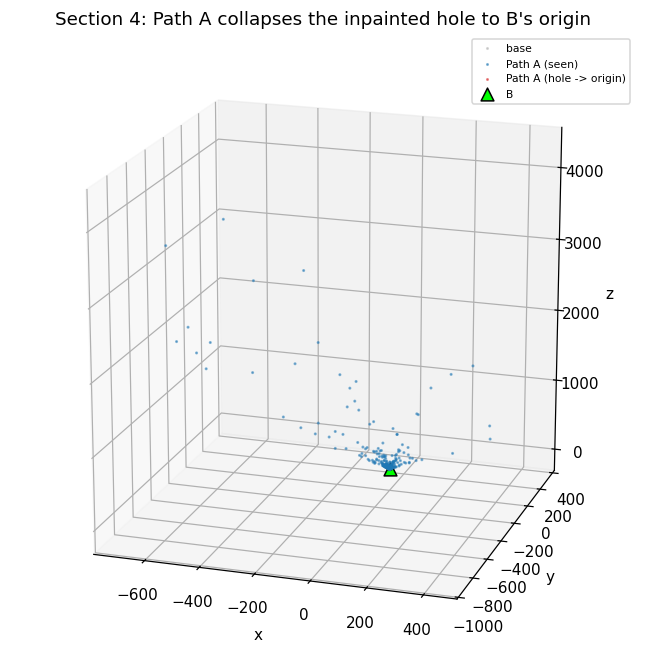

In [8]:
# Simulate the inpaint hole: a rectangle the generator would fill, where the splats
# have no coverage -> depth comes back 0 from gsplat (alpha 0).
hole = np.zeros_like(alpha_B, dtype=bool)
h0, h1 = int(0.30 * H_B), int(0.70 * H_B)
w0, w1 = int(0.62 * W_B), int(0.98 * W_B)
hole[h0:h1, w0:w1] = True
depth_A = depth_B.copy()
depth_A[hole] = 0.0                                   # what gsplat returns where alpha==0

pts_A_world = unproject(depth_A, K_B, c2w_B).reshape(-1, 3).cpu().numpy()
hole_world  = unproject(depth_A, K_B, c2w_B)[torch.from_numpy(hole).to(device)].cpu().numpy()
B_center = c2w_B[:3, 3].cpu().numpy()
print(f"hole pixels: {hole.mean():.1%}")
print(f"hole points: mean={hole_world.mean(0).round(3)}  (B center={B_center.round(3)})")
print(f"hole points -> B center: mean dist={np.linalg.norm(hole_world - B_center, axis=1).mean():.4f} "
      f"(they collapse onto the camera origin)")

show_overlay([(base_np, "0.7", "base"),
              (pts_A_world[~hole.reshape(-1)], "tab:blue", "Path A (seen)"),
              (hole_world, "tab:red", "Path A (hole -> origin)")],
             "Section 4: Path A collapses the inpainted hole to B's origin",
             cams=[(c2w_B.cpu().numpy(), "lime", "B")])

## Section 5 — Path B: re-estimate with DA3 + scale-align

Treat B's render as the *generated/inpainted* frame and recover its geometry with DA3,
then place it into the base world W. Two sub-methods:

- **5a — Joint DA3 pass** over `base frames + B` (mirrors `splat_trainer.append_video`):
  poses come out in a fresh frame W′; align W′→W using the **base** correspondence via
  **point-A similarity** *and* **Umeyama Sim3**, then recover B's pose + scale-corrected depth.
- **5b — Single-image DA3** on B (the realistic inpaint case: we *know* B's pose because
  the user created the camera, we only need depth at the right **scale**). Recover scale
  three ways — **overlap fit** (DA3 depth vs splat depth on α>0), **MoGe-overlap**, and
  **MoGe-absolute** (the `demo_server` DA3↔MoGe LS fit) — and compare.

[INFO ] Processed Images Done taking 0.03207564353942871 seconds. Shape:  torch.Size([11, 3, 294, 504])
[INFO ] Selecting reference view using strategy: saddle_balanced
b_idx: tensor([9], device='cuda:0')
[INFO ] Model Forward Pass Done. Time: 0.5244708061218262 seconds
[INFO ] Conversion to Prediction Done. Time: 0.005322456359863281 seconds
joint DA3: N=11 (base 10 + B 1)  HxW=294x504
point-A : depth scale s=1.0586 | B pose err pos=0.3685 ang=1.01°
umeyama : sim3 s=0.9397 base-residual=0.0039 | B pose err pos=0.3773 ang=8.85°


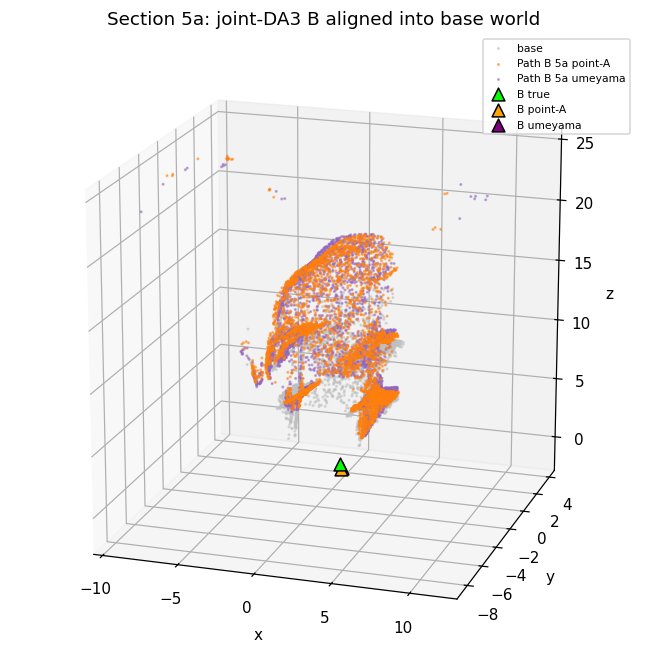

In [9]:
# ---- 5a: joint DA3 pass + align to base world W -------------------------------
scratch = tempfile.mkdtemp(prefix="camalign_", dir=os.getcwd())
B_png = os.path.join(scratch, "B.png")
cv2.imwrite(B_png, cv2.cvtColor(rgb_B, cv2.COLOR_RGB2BGR))

joint = da3_pack(da3_model, list(base_paths) + [B_png])
nb = len(base_paths)
print(f"joint DA3: N={joint.N} (base {nb} + B 1)  HxW={joint.H}x{joint.W}")

ref_c2w = base_data.c2w[:nb].cpu().numpy()            # known base poses in W
ref_w2c = base_data.w2c[:nb].cpu().numpy()
est_w2c = joint.w2c[:nb].cpu().numpy()                # joint poses for the SAME base frames (W')

# --- point-A similarity (exactly splat_trainer.append_video 1456-1485) ----------
s_pA = st._estimate_depth_scale(base_data.depth[0:1], joint.depth[0:1])
R_align = base_data.c2w[0, :3, :3] @ joint.c2w[0, :3, :3].transpose(0, 1)
A_old, A_j = base_data.c2w[0, :3, 3], joint.c2w[0, :3, 3]
def apply_pA(c2w_batch):
    R = R_align[None] @ c2w_batch[:, :3, :3]
    c = A_old[None] + s_pA * (R_align[None] @ (c2w_batch[:, :3, 3] - A_j).unsqueeze(-1)).squeeze(-1)
    out = torch.eye(4, device=device).repeat(c2w_batch.shape[0], 1, 1)
    out[:, :3, :3] = R; out[:, :3, 3] = c
    return out
B_pA = apply_pA(joint.c2w[nb:])[0].cpu().numpy()
pos_pA, ang_pA = pose_errors(B_pA, c2w_B.cpu().numpy())

# --- Umeyama Sim3 fit on base frames (pick arg order by residual) ---------------
def fit_umeyama(a, b, joint_c2w_base):
    r, t, s = align_poses_umeyama(a, b)
    aligned = apply_sim3_to_c2w(joint_c2w_base, r, t, s)
    res = float(np.linalg.norm(aligned[:, :3, 3] - ref_c2w[:, :3, 3], axis=1).mean())
    return r, t, s, res
jc_base = joint.c2w[:nb].cpu().numpy()
cands = [fit_umeyama(est_w2c, ref_w2c, jc_base), fit_umeyama(ref_w2c, est_w2c, jc_base)]
r, t, s_um, res_um = min(cands, key=lambda x: x[3])
B_um = apply_sim3_to_c2w(joint.c2w[nb:].cpu().numpy(), r, t, s_um)[0]
pos_um, ang_um = pose_errors(B_um, c2w_B.cpu().numpy())
print(f"point-A : depth scale s={s_pA:.4f} | B pose err pos={pos_pA:.4f} ang={ang_pA:.2f}°")
print(f"umeyama : sim3 s={s_um:.4f} base-residual={res_um:.4f} | B pose err pos={pos_um:.4f} ang={ang_um:.2f}°")

# Scale-correct B's joint depth into W units (append_video: new_depth *= s_pA) and backproject.
depth_B_joint = (joint.depth[nb] * s_pA).cpu().numpy()
K_B_joint     = joint.K[nb].cpu().numpy()
valid_j = depth_B_joint > 0
ptsB_pA = unproject(depth_B_joint, K_B_joint, B_pA)[torch.from_numpy(valid_j).to(device)].cpu().numpy()
ptsB_um = unproject(depth_B_joint, K_B_joint, B_um)[torch.from_numpy(valid_j).to(device)].cpu().numpy()
show_overlay([(base_np, "0.75", "base"),
              (ptsB_pA, "tab:orange", "Path B 5a point-A"),
              (ptsB_um, "tab:purple", "Path B 5a umeyama")],
             "Section 5a: joint-DA3 B aligned into base world",
             cams=[(c2w_B.cpu().numpy(), "lime", "B true"),
                   (B_pA, "orange", "B point-A"), (B_um, "purple", "B umeyama")])

[INFO ] Processed Images Done taking 0.0027103424072265625 seconds. Shape:  torch.Size([1, 3, 294, 504])
[INFO ] Model Forward Pass Done. Time: 0.0983574390411377 seconds
[INFO ] Conversion to Prediction Done. Time: 0.00041174888610839844 seconds
single-image scales (DA3 depth must be multiplied by s to reach base units):
  s_overlap        = 2.4416   (DA3 vs splat depth on alpha>0 overlap)  <- correct for incremental
  s_moge_overlap   = 4.8932   (MoGe vs splat depth on overlap)
  s_da3_to_moge    = 1.9325   (demo_server LS; metric, NOT base-scale unless scene is metric)


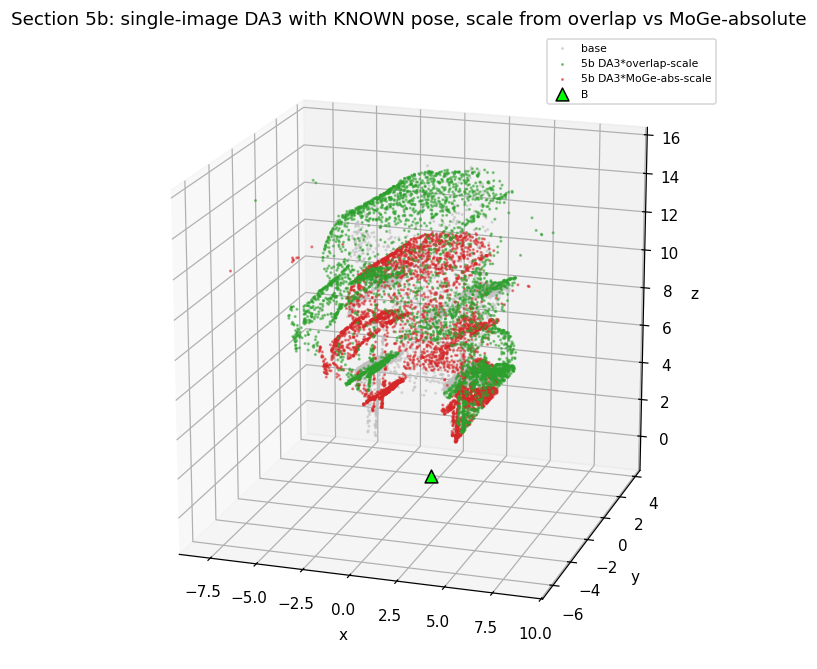

In [10]:
# ---- 5b: single-image DA3 on B; KNOWN pose c2w_B, recover only SCALE -----------
img_B = torch.from_numpy(rgb_B)                       # (H,W,3) uint8
_, da3_depth, da3_K, da3_mask = _da3_infer_depth_intrinsics_single(da3_model, img_B, (H_B, W_B))
da3_depth = da3_depth.cpu().numpy(); da3_K = da3_K.cpu().numpy(); da3_mask = da3_mask.cpu().numpy() > 0.5

# overlap = pixels seen by the splats AND valid in DA3 -> robust scale to base units
ov = seen & da3_mask & (da3_depth > 0) & (depth_B > 0)
s_overlap = float(np.median(depth_B[ov] / da3_depth[ov]))      # multiply DA3 depth by this

# MoGe (lightweight): metric depth + the demo_server DA3<->MoGe LS scale
moge_model = load_moge_model(device)
_, moge_depth, _, moge_mask = moge_infer_depth_intrinsics(
    moge_model, img_B.cpu(), depth_pred_hw=(H_B, W_B), target_hw=(H_B, W_B))
moge_model.cpu()
moge_depth = moge_depth.cpu().numpy(); moge_mask = moge_mask.cpu().numpy() > 0.5
ov_m = seen & moge_mask & (moge_depth > 0) & (moge_depth < 999) & (depth_B > 0)
s_moge_overlap = float(np.median(depth_B[ov_m] / moge_depth[ov_m]))   # MoGe->base via overlap
# demo_server LS fit (inverse-depth): DA3 depth -> MoGe metric scale (NO scene overlap)
ov_dm = da3_mask & moge_mask & (da3_depth > 0) & (moge_depth > 0) & (moge_depth < 999)
inv_da3, inv_moge = 1.0 / (da3_depth[ov_dm] + 1e-6), 1.0 / (moge_depth[ov_dm] + 1e-6)
s_da3_to_moge = float((inv_da3 * inv_moge).sum() / (inv_da3 * inv_da3).sum())  # da3 *= this -> metric

print(f"single-image scales (DA3 depth must be multiplied by s to reach base units):")
print(f"  s_overlap        = {s_overlap:.4f}   (DA3 vs splat depth on alpha>0 overlap)  <- correct for incremental")
print(f"  s_moge_overlap   = {s_moge_overlap:.4f}   (MoGe vs splat depth on overlap)")
print(f"  s_da3_to_moge    = {s_da3_to_moge:.4f}   (demo_server LS; metric, NOT base-scale unless scene is metric)")

ptsB_s = unproject(da3_depth * s_overlap, da3_K, c2w_B).reshape(-1, 3)[torch.from_numpy(da3_mask.reshape(-1)).to(device)].cpu().numpy()
ptsB_moge = unproject(da3_depth * s_da3_to_moge, da3_K, c2w_B).reshape(-1, 3)[torch.from_numpy(da3_mask.reshape(-1)).to(device)].cpu().numpy()
show_overlay([(base_np, "0.75", "base"),
              (ptsB_s, "tab:green", "5b DA3*overlap-scale"),
              (ptsB_moge, "tab:red", "5b DA3*MoGe-abs-scale")],
             "Section 5b: single-image DA3 with KNOWN pose, scale from overlap vs MoGe-absolute",
             cams=[(c2w_B.cpu().numpy(), "lime", "B")])

## Section 6 — Compare & diagnose

One overlay of base + Path A + Path B, and a metrics table in the same format as the
live diagnostics (`demo._log_target_result`, `splat_trainer.append_video`): camera
**position error**, **angular error**, and **depth-scale ratio** (recovered ÷ true).

method                   pose           pos_err    ang°  scale_ratio   note
--------------------------------------------------------------------------------------
A  splat-depth (hole=0)  n/a (uses true pose)    0.0000    0.00        0.000   hole -> origin
B  5a point-A            recovered       0.3685    1.01        1.318   s=1.059
B  5a umeyama            recovered       0.3773    8.85        1.318   s=0.940
B  5b overlap            known pose      0.0000    0.01        1.227   s=2.442
B  5b MoGe-abs           known pose      0.0000    0.00        0.971   s=1.932

scene_scale=2.192  baseline=0.548
DIAGNOSIS:
 - Section 3 ~0 nearest-dist  => OpenCV w2c/c2w + intrinsics are correct (NOT a convention bug).
 - Path A collapses disoccluded pixels to B's origin (scale_ratio->0)  => the demo's literal bug.
 - Path B 5a recovers B's pose; residual/scale_ratio drift grows with baseline (no-anchor limit).
 - Path B 5b with a KNOWN pose lines up when scale is fit on OVERLAP; MoGe-absolute is o

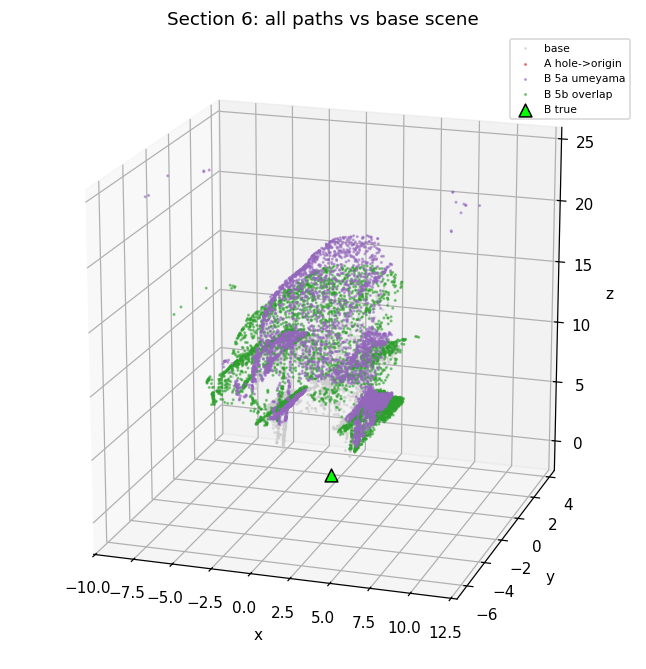

In [11]:
def scale_ratio(pts, c2w_ref):
    # mean recovered radius from B center / mean true radius (==1 if scale perfect)
    c = np.asarray(c2w_ref)[:3, 3]
    return float(np.linalg.norm(np.asarray(pts) - c, axis=1).mean())

true_radius = scale_ratio(pts_B_world, c2w_B.cpu().numpy())
rows = [
    ("A  splat-depth (hole=0)", "n/a (uses true pose)", 0.0, 0.0,
     scale_ratio(hole_world, c2w_B.cpu().numpy()) / true_radius, "hole -> origin"),
    ("B  5a point-A",  "recovered", pos_pA, ang_pA, scale_ratio(ptsB_pA, B_pA) / true_radius, f"s={s_pA:.3f}"),
    ("B  5a umeyama",  "recovered", pos_um, ang_um, scale_ratio(ptsB_um, B_um) / true_radius, f"s={s_um:.3f}"),
    ("B  5b overlap",  "known pose", *pose_errors(c2w_B.cpu().numpy(), c2w_B.cpu().numpy()),
     scale_ratio(ptsB_s, c2w_B.cpu().numpy()) / true_radius, f"s={s_overlap:.3f}"),
    ("B  5b MoGe-abs", "known pose", 0.0, 0.0,
     scale_ratio(ptsB_moge, c2w_B.cpu().numpy()) / true_radius, f"s={s_da3_to_moge:.3f}"),
]
print(f"{'method':24s} {'pose':12s} {'pos_err':>9s} {'ang°':>7s} {'scale_ratio':>12s}   note")
print("-" * 86)
for name, pose, pe, ae, sr, note in rows:
    print(f"{name:24s} {pose:12s} {pe:9.4f} {ae:7.2f} {sr:12.3f}   {note}")
print(f"\nscene_scale={scene_scale:.3f}  baseline={BASELINE_FRAC*scene_scale:.3f}")

show_overlay([(base_np, "0.8", "base"),
              (hole_world, "tab:red", "A hole->origin"),
              (ptsB_um, "tab:purple", "B 5a umeyama"),
              (ptsB_s, "tab:green", "B 5b overlap")],
             "Section 6: all paths vs base scene",
             cams=[(c2w_B.cpu().numpy(), "lime", "B true")])
print(
"DIAGNOSIS:\n"
" - Section 3 ~0 nearest-dist  => OpenCV w2c/c2w + intrinsics are correct (NOT a convention bug).\n"
" - Path A collapses disoccluded pixels to B's origin (scale_ratio->0)  => the demo's literal bug.\n"
" - Path B 5a recovers B's pose; residual/scale_ratio drift grows with baseline (no-anchor limit).\n"
" - Path B 5b with a KNOWN pose lines up when scale is fit on OVERLAP; MoGe-absolute is off because\n"
"   the base scene is DA3-native (arbitrary) scale, not metric.")

## Section 7 — Bisection knobs

Sweeps to localize the failure: (a) **baseline** A→B (small overlap → pure-novel) to
expose no-anchor scale drift; (b) **intrinsics** — DA3-predicted K vs the demo's
hardcoded `fov=60°` K (`demo.py:844`, `inpainter.py:247`) to check for an intrinsics
mismatch between the camera we send and what DA3 assumes.

In [12]:
# (a) baseline sweep: how Path-B 5b overlap alignment degrades as B leaves the seen region
print("baseline sweep (Path B 5b, known pose, overlap-scale):")
print(f"{'baseline/ss':>11s} {'seen%':>7s} {'overlap_px':>11s} {'s_overlap':>10s} {'B-pts->base med':>16s}")
for bf in [0.1, 0.25, 0.5, 1.0, 2.0]:
    cB = make_B(c2w_A, bf); wB = torch.linalg.inv(cB)
    rb, db, ab = render_scene(base_scene, wB, K_B, H_B, W_B)
    sn = ab > 0.5
    imgb = torch.from_numpy(rb)
    _, dd, dk, dm = _da3_infer_depth_intrinsics_single(da3_model, imgb, (H_B, W_B))
    dd = dd.cpu().numpy(); dk = dk.cpu().numpy(); dm = dm.cpu().numpy() > 0.5
    ov = sn & dm & (dd > 0) & (db > 0)
    if ov.sum() < 200:
        print(f"{bf:11.2f} {sn.mean():7.1%} {int(ov.sum()):11d} {'--':>10s} {'(too little overlap)':>16s}")
        continue
    so = float(np.median(db[ov] / dd[ov]))
    pw = unproject(dd * so, dk, cB).reshape(-1, 3)[torch.from_numpy(dm.reshape(-1)).to(device)].cpu().numpy()
    d2, _ = tree.query(pw[np.random.choice(pw.shape[0], min(8000, pw.shape[0]), replace=False)])
    print(f"{bf:11.2f} {sn.mean():7.1%} {int(ov.sum()):11d} {so:10.4f} {np.median(d2):16.4f}")

baseline sweep (Path B 5b, known pose, overlap-scale):
baseline/ss   seen%  overlap_px  s_overlap  B-pts->base med
[INFO ] Processed Images Done taking 0.0023398399353027344 seconds. Shape:  torch.Size([1, 3, 294, 504])
[INFO ] Model Forward Pass Done. Time: 0.19398713111877441 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0003857612609863281 seconds
       0.10   63.0%       93384     1.7328           0.2082
[INFO ] Processed Images Done taking 0.002589702606201172 seconds. Shape:  torch.Size([1, 3, 294, 504])
[INFO ] Model Forward Pass Done. Time: 0.08284330368041992 seconds
[INFO ] Conversion to Prediction Done. Time: 0.00038623809814453125 seconds
       0.25   63.3%       93865     2.4418           0.5059
[INFO ] Processed Images Done taking 0.003428220748901367 seconds. Shape:  torch.Size([1, 3, 294, 504])
[INFO ] Model Forward Pass Done. Time: 0.08323121070861816 seconds
[INFO ] Conversion to Prediction Done. Time: 0.00041222572326660156 seconds
       0.50   60.6%     

DA3 K      = fx=429.2 fy=426.3 cx=252.0 cy=147.0
fov=60 K   = fx=254.6 fy=254.6 cx=252.0 cy=147.0
backproject->base median dist:  correct K = 0.0336   fov60 K = 1.2500
=> if the demo sends a camera whose K disagrees with DA3's predicted K, geometry shears/shifts.


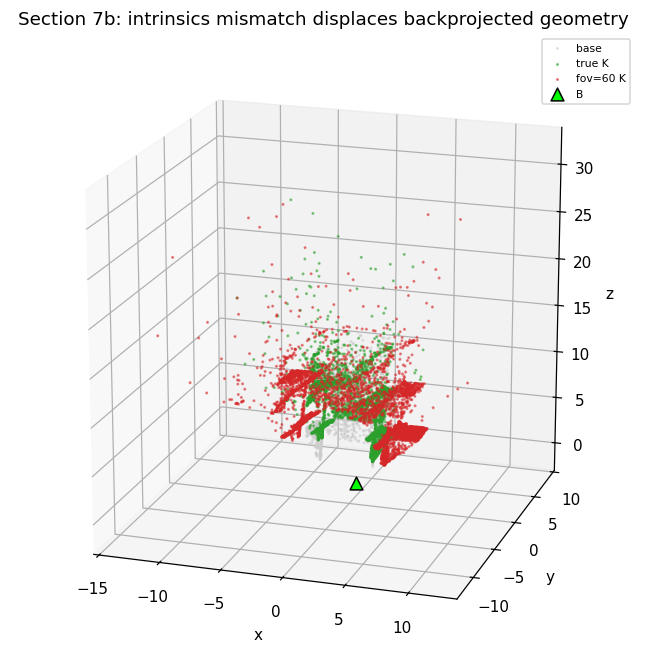

In [13]:
# (b) intrinsics mismatch: backproject B's TRUE splat depth with a WRONG K (fov=60 hardcode)
#     vs the correct K, to quantify how an intrinsics mismatch alone displaces geometry.
fy60 = 0.5 * H_B / math.tan(0.5 * math.radians(60.0))
K_fov60 = np.array([[fy60, 0, W_B / 2.0], [0, fy60, H_B / 2.0], [0, 0, 1]], np.float32)
seen_t = torch.from_numpy(seen).to(device)
pts_trueK = unproject(depth_B, K_B, c2w_B)[seen_t].cpu().numpy()
pts_wrongK = unproject(depth_B, K_fov60, c2w_B)[seen_t].cpu().numpy()
dt, _ = tree.query(pts_trueK[np.random.choice(pts_trueK.shape[0], 8000, replace=False)])
dw, _ = tree.query(pts_wrongK[np.random.choice(pts_wrongK.shape[0], 8000, replace=False)])
print(f"DA3 K      = fx={K_B[0,0]:.1f} fy={K_B[1,1]:.1f} cx={K_B[0,2]:.1f} cy={K_B[1,2]:.1f}")
print(f"fov=60 K   = fx={fy60:.1f} fy={fy60:.1f} cx={W_B/2:.1f} cy={H_B/2:.1f}")
print(f"backproject->base median dist:  correct K = {np.median(dt):.4f}   fov60 K = {np.median(dw):.4f}")
print("=> if the demo sends a camera whose K disagrees with DA3's predicted K, geometry shears/shifts.")
show_overlay([(base_np, "0.8", "base"),
              (pts_trueK, "tab:green", "true K"),
              (pts_wrongK, "tab:red", "fov=60 K")],
             "Section 7b: intrinsics mismatch displaces backprojected geometry",
             cams=[(c2w_B.cpu().numpy(), "lime", "B")])

## Conclusions & next steps

- **Convention is fine** (Section 3): viser→OpenCV `w2c` round-trips to ~0; backprojected
  depth lands on the base scene. The misalignment is **not** a coordinate/basis bug.
- **Path A is the demo's literal bug** (Section 4): the inpaint append uses splat-rendered
  depth, so the newly-painted (disoccluded) pixels get depth 0 and **collapse to the camera
  origin** — exactly "reconstructs somewhere else."
- **Path B fixes it** by re-estimating depth with DA3 and grounding it:
  - With a **known camera** (our case — the user creates B), fit the DA3 depth **scale on
    the overlap** with the existing splats (Section 5b `s_overlap`). **MoGe-absolute scale
    does not line up** unless the whole base scene is metric.
  - Without a known pose, the **point-A / Umeyama** alignment recovers B's pose, but scale
    **drifts as the new view leaves the seen region** (Section 7a — the documented no-anchor limit).
- **Intrinsics must match** what DA3 assumes (Section 7b): sending a `fov=60°` K when DA3
  predicts a different K shears the geometry.

**Proposed demo fix (follow-up, out of scope here):** in `inpainter._on_add_frame_click`,
for pixels the inpainter painted (mask ∪ α≈0), replace splat depth with **DA3 depth scaled
by the overlap factor** to the splat depth on the seen region, using the camera's true K.